In [ ]:
# ============================================================================
# UTILITY: 빠른 EDA 원라이너 모음
# ============================================================================
"""
# 중복 체크
df.duplicated().sum()
df[df.duplicated(keep=False)].sort_values(by='key_col')
 
# 특정 조건 필터
df[df['col'] > threshold]
df.query('col1 > 100 & col2 == "A"')
 
# 그룹별 집계
df.groupby('cat_col')['num_col'].agg(['count', 'mean', 'median', 'std'])
df.pivot_table(values='num_col', index='cat1', columns='cat2', aggfunc='mean')
 
# 빈도 테이블
pd.crosstab(df['col1'], df['col2'], margins=True)
 
# 상관계수 (Spearman - 비선형에 더 robust)
df[num_cols].corr(method='spearman')
 
# 정규성 검정
from scipy.stats import shapiro, normaltest
stat, p = shapiro(df['col'].dropna().sample(min(5000, len(df))))
 
# VIF (다중공선성)
# from statsmodels.stats.outliers_influence import variance_inflation_factor
# vif = pd.DataFrame()
# vif['feature'] = num_cols
# vif['VIF'] = [variance_inflation_factor(df[num_cols].dropna().values, i) 
#                for i in range(len(num_cols))]
 
# 빠른 프로파일링 (라이브러리 설치 필요)
# import ydata_profiling
# profile = ydata_profiling.ProfileReport(df, minimal=True)
# profile.to_file('eda_report.html')
"""

# 0. Setup & Imports

In [43]:
# ============================================================================
# 0. SETUP & IMPORTS
# ============================================================================
import os
import sys
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print(f"sys.platform: {sys.platform}") # (Linux/Docker vs Windows)
print(f"sys.executable: {sys.executable}") # 커널경로 확인 
print(f"os.pwd: {os.getcwd()}")
 
# 컬럼(열) 제한해제 
pd.set_option('display.max_columns', None)      # 전체 표시 (제한 해제)

# 선택사항 
# pd.set_option('display.max_rows', 100)   # 행 제한100개까지
# pd.set_option('display.max_colwidth', 50)  #셀 내 텍스트 잘림 방지 50자까지
# pd.set_option('display.float_format', '{:.2f}'.format) #소수점 자릿수
# pd.reset_option('all') # 전부 원래대로 초기화

# # 한글 폰트 설정 (환경에 맞게 택 1)
# plt.rcParams['font.family'] = 'Malgun Gothic'      # Windows
# # plt.rcParams['font.family'] = 'AppleGothic'      # Mac
# # plt.rcParams['font.family'] = 'NanumGothic'      # Linux / Colab
# plt.rcParams['axes.unicode_minus'] = False
#  
# # Pandas 출력 옵션
# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', 100)
# pd.set_option('display.float_format', '{:.2f}'.format)
# pd.set_option('display.max_colwidth', 50)
#  
# # 시각화 기본 스타일
# sns.set_style('whitegrid')
# sns.set_palette('Set2')
# FIGSIZE = (12, 6)


sys.platform: linux
sys.executable: /usr/bin/python3
os.pwd: /home/jovyan/d/git/01_mdls_ds8_open/08_dl/260318_dl_DKTC


# 1. DATA LOADING & FIRST LOOK

In [63]:
df.head(2)

,dataset,doc_id,session_id,turn_id,speaker_id,speaker_role,text,topic_raw,topic_large,topic_medium,topic_small,category,source_file,speaker_age,speaker_gender,speaker_occupation,session_summary,prev_session_id,prev_aggregated_summary,context_query,context_document_title
0,11,DAILY-003794-AP600003-WZ000002-02_03_04-S2.json,003794-1,1,E0053,speaker1,오늘은 관광지에 대해서 물어보려고 하는데 그런 것도 잘 알고 있어?,사물,취미,관광/감상,사물,취미,DAILY-003794-AP600003-WZ000002-02_03_04-S2.json,30대,여성,사무직,질문자가 경주 봉황로에 대해 질문했고 챗봇은 봉황로(Bonghwang-ro)는 경상...,NaN,"{""apprentice"": [], ""wizard"": []}",NaN,NaN
1,11,DAILY-003794-AP600003-WZ000002-02_03_04-S2.json,003794-1,2,F0053,speaker2,네 그럼요. 뭐든 물어보세요.,사물,취미,관광/감상,사물,취미,DAILY-003794-AP600003-WZ000002-02_03_04-S2.json,60대 이상,여성,주부,질문자가 경주 봉황로에 대해 질문했고 챗봇은 봉황로(Bonghwang-ro)는 경상...,NaN,"{""apprentice"": [], ""wizard"": []}",NaN,NaN


In [ ]:
# ============================================================================
# 1. DATA LOADING & FIRST LOOK
# ============================================================================
# >>> 판단 포인트: shape, dtypes, head/tail을 보고
#     "이 데이터가 내가 기대한 구조와 일치하는가?" 를 먼저 확인
#     행 수가 예상보다 적거나 많으면 데이터 수집 과정 의심.
 
# --- 로딩 ---
base_dir = r"/home/jovyan/d/git/01_mdls_ds8_open/08_dl/260318_dl_DKTC/00_data_csv"
df = pd.read_csv(f"{base_dir}/011_train_utterances.csv") # encoding='cp949' or 'utf-8'
# df = pd.read_csv('data.csv', parse_dates=['date_col'])
# df = pd.read_excel('data.xlsx', sheet_name=0)
 
# --- 기본 확인 ---
print("\n--- SHAPE ---")
print("SHAPE:", df.shape)
print("\n")
 
print("\n--- HEAD ---")
print(df.head())
 
print("\n--- TAIL ---")
print(df.tail())
 
print("\n--- INFO ---")
df.info()
 
print("\n--- DTYPES ---")
print(df.dtypes.value_counts())
 
# 컬럼 리스트 한눈에 보기
print("\n--- COLUMNS ---")
for i, col in enumerate(df.columns):
    print(f"  [{i:3d}] {col:30s}  dtype={df[col].dtype}")


In [53]:
# 특정 컬럼 지정해서 dtype 변환
# df.info() , df.head() 검토 후 필요시 실행
def fix_dtypes(df, to_int=None, to_float=None, to_cat=None, to_date=None):
    """컬럼별 dtype 일괄 변환"""
    df = df.copy()
    if to_int:
        for col in to_int:
            df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')
    if to_float:
        for col in to_float:
            df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', ''), errors='coerce')
    if to_cat:
        for col in to_cat:
            df[col] = df[col].astype('category')
    if to_date:
        for col in to_date:
            df[col] = pd.to_datetime(df[col], errors='coerce')
    return df

# 사용 예시
# df = fix_dtypes(df,
#     to_int=['col_a', 'col_b'],
#     to_float=['price', 'amount'],
#     to_cat=['grade', 'region'],
#     to_date=['created_at'])

df = fix_dtypes(df,
    to_cat=['dataset','speaker_role', 'topic_raw', 'topic_large', 
            'topic_medium', 'topic_small', 'category', 'speaker_age',
            'speaker_gender', 'speaker_occupation'],
    to_int=['turn_id'])

# 수치형 / 범주형 컬럼 구분
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
date_cols = df.select_dtypes(include=['datetime64']).columns.tolist()
 
print(f"\n수치형({len(num_cols)}): {num_cols}")
print(f"범주형({len(cat_cols)}): {cat_cols}")
print(f"날짜형({len(date_cols)}): {date_cols}")


수치형(1): ['turn_id']
범주형(20): ['dataset', 'doc_id', 'session_id', 'speaker_id', 'speaker_role', 'text', 'topic_raw', 'topic_large', 'topic_medium', 'topic_small', 'category', 'source_file', 'speaker_age', 'speaker_gender', 'speaker_occupation', 'session_summary', 'prev_session_id', 'prev_aggregated_summary', 'context_query', 'context_document_title']
날짜형(0): []


In [ ]:
# for 루프이용 컬럼 .value_counts()
for col in df.select_dtypes(include=['object','category']).columns:
    print(f"\n--- {col} (unique={df[col].nunique()}) ---")
    print(df[col].value_counts())

In [55]:
# 전체 컬럼 요약을 하나의 DataFrame으로
summary = pd.DataFrame({
    'dtype': df.dtypes,
    'nunique': df.nunique(),
    'missing': df.isnull().sum(),
    'missing_pct': (df.isnull().mean() * 100).round(2),
    'top': df.mode().iloc[0],
    'top_count': df.apply(lambda x: x.value_counts().iloc[0] if x.nunique() > 0 else 0),
    'top_pct': df.apply(lambda x: (x.value_counts().iloc[0] / len(df) * 100).round(2) if x.nunique() > 0 else 0)
})
summary

,dtype,nunique,missing,missing_pct,top,top_count,top_pct
dataset,category,1,0,0.00,11,1923481,100.00
doc_id,object,49206,0,0.00,DAILY-027124-AP604335-WZ000001-01_03_10-S4.json,112,0.01
session_id,object,122605,0,0.00,155949-1,32,0.00
turn_id,Int64,30,0,0.00,1,122613,6.37
speaker_id,object,1688,0,0.00,GE0108,20000,1.04
speaker_role,category,2,0,0.00,speaker2,962030,50.02
text,object,1654798,1,0.00,"좋아요, 질문해 주셔서 감사합니다. 궁금한 것이 있을 때 언제든 다시 오세요. 행운...",1868,0.10
topic_raw,category,10,0,0.00,인물,405125,21.06
topic_large,category,3,0,0.00,취미,931964,48.45
topic_medium,category,13,0,0.00,스포츠,448710,23.33


In [ ]:
# 특정 컬럼의 value_counts 자체를 보기 좋게 보려면:
def vc_df(df, col):
    vc = df[col].value_counts()
    return pd.DataFrame({
        'count': vc,
        'pct': (vc / len(df) * 100).round(2),
        'cum_pct': (vc.cumsum() / len(df) * 100).round(2)
    })

# 사용
vc_df(df, 'speaker_occupation')

In [ ]:
# 전체 범주형 컬럼을 한번에 돌리면서 각각 df로 찍고 싶으면
for col in df.select_dtypes(include='object').columns:
    print(f"\n{'='*40} {col} {'='*40}")
    display(vc_df(df, col))

# 2. MISSING VALUES 분석

In [58]:
# ============================================================================
# 2. MISSING VALUES 분석
# ============================================================================
# >>> 판단 포인트:
#     - 결측률 50% 이상 → 해당 컬럼 제거 고려
#     - 결측률 5% 미만 → 단순 대체(평균/중앙값/최빈값) 가능
#     - 결측 패턴이 랜덤인지, 특정 조건에서 집중되는지 확인 필수
#       (MCAR / MAR / MNAR 구분이 후속 처리 전략을 결정함)
 
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct,
    'dtype': df.dtypes
}).sort_values('missing_pct', ascending=False)

missing_df = missing_df[missing_df['missing_count'] > 0]
print("\n--- MISSING VALUES ---")
missing_df

 


--- MISSING VALUES ---


,missing_count,missing_pct,dtype
context_document_title,1645740,85.56,object
context_query,1645740,85.56,object
prev_session_id,771270,40.10,object
text,1,0.00,object


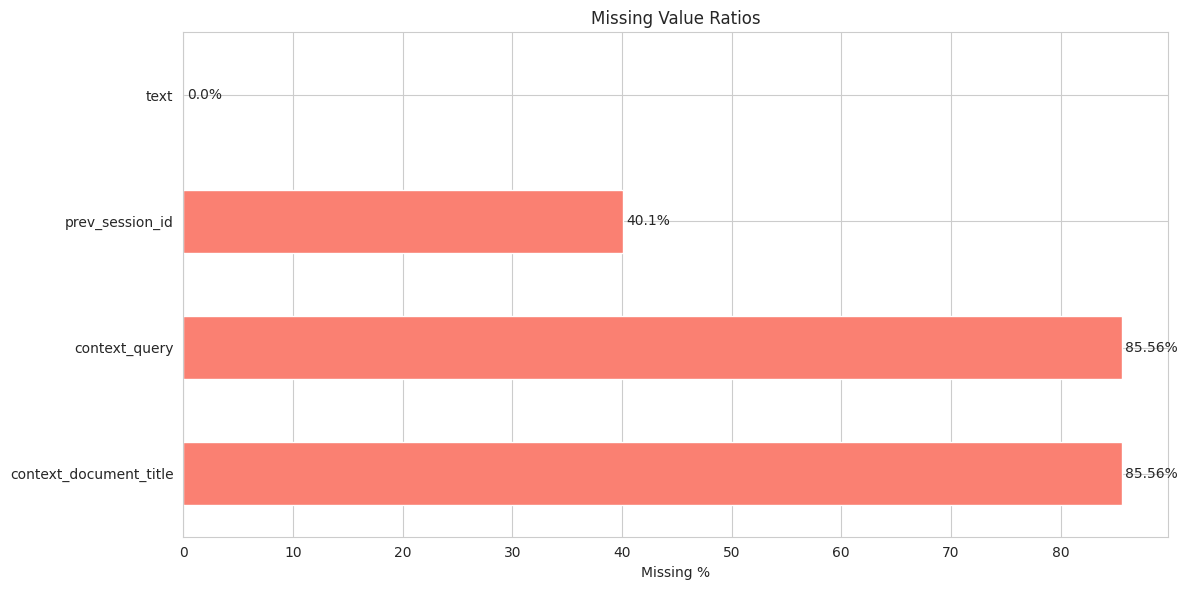

In [59]:
 
# 결측 비율 시각화
if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=FIGSIZE)
    missing_df['missing_pct'].plot(kind='barh', ax=ax, color='salmon')
    ax.set_xlabel('Missing %')
    ax.set_title('Missing Value Ratios')
    for i, v in enumerate(missing_df['missing_pct']):
        ax.text(v + 0.3, i, f'{v}%', va='center')
    plt.tight_layout()
    plt.show()
 


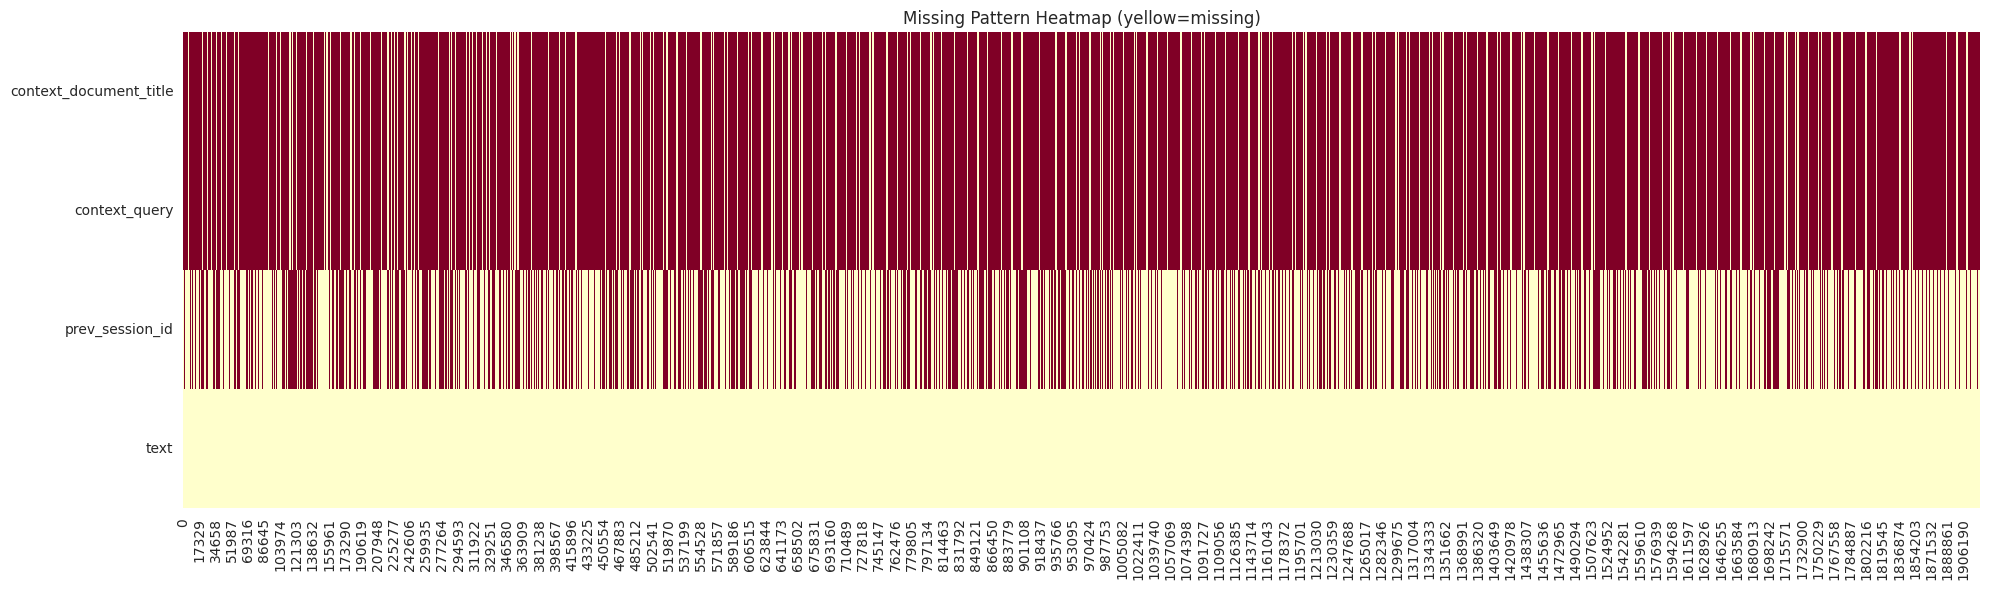

In [60]:
# 결측 패턴 히트맵 (msno 없이 간단 버전)
if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(min(20, len(df.columns)), 6))
    sns.heatmap(df[missing_df.index].isnull().T, cbar=False, cmap='YlOrRd', ax=ax)
    ax.set_title('Missing Pattern Heatmap (yellow=missing)')
    plt.tight_layout()
    plt.show()

# 4. 기술통계 (DESCRIPTIVE STATISTICS)

In [61]:
# ============================================================================
# 4. 기술통계 (DESCRIPTIVE STATISTICS)
# ============================================================================
# >>> 판단 포인트:
#     - mean vs median 차이가 크면 → 비대칭(skewed) 분포, 이상치 의심
#     - std가 mean보다 크면 → 분산이 매우 큼, 스케일링 필요성
#     - min/max가 비상식적이면 → 입력 오류 또는 이상치

df.describe()

,turn_id
count,1923481.00
mean,8.36
std,4.55
min,1.00
25%,4.00
50%,8.00
75%,12.00
max,30.00


In [62]:
print("\n--- 수치형 기술통계 ---")
desc_num = df[num_cols].describe().T
desc_num['skew'] = df[num_cols].skew()
desc_num['kurt'] = df[num_cols].kurtosis()
desc_num['iqr'] = desc_num['75%'] - desc_num['25%']
desc_num['cv'] = (desc_num['std'] / desc_num['mean']).round(3)  # 변동계수

desc_num



--- 수치형 기술통계 ---


,count,mean,std,min,25%,50%,75%,max,skew,kurt,iqr,cv
turn_id,1923481.00,8.36,4.55,1.00,4.00,8.00,12.00,30.00,0.02,-1.18,8.00,0.54


In [64]:
print("\n--- 범주형 기술통계 ---")
if cat_cols:
    desc_cat = df[cat_cols].describe().T
desc_cat


--- 범주형 기술통계 ---


,count,unique,top,freq
dataset,1923481,1,11,1923481
doc_id,1923481,49206,DAILY-027124-AP604335-WZ000001-01_03_10-S4.json,112
session_id,1923481,122605,220567-2,32
speaker_id,1923481,1688,GE0108,20000
speaker_role,1923481,2,speaker2,962030
text,1923480,1654798,"좋아요, 질문해 주셔서 감사합니다. 궁금한 것이 있을 때 언제든 다시 오세요. 행운...",1868
topic_raw,1923481,10,인물,405125
topic_large,1923481,3,취미,931964
topic_medium,1923481,13,스포츠,448710
topic_small,1923481,10,인물,405125


# 3. DATA TYPES 점검 & 변환

In [66]:
# ============================================================================
# 3. DATA TYPES 점검 & 변환
# ============================================================================
# >>> 판단 포인트:
#     - 숫자인데 object로 읽힌 컬럼 → 쉼표, 공백, 특수문자 섞여있을 가능성
#     - 범주형인데 int로 읽힌 컬럼 (예: 0/1 flag, 등급코드) → 의도적 구분 필요
#     - unique 수가 매우 적은 수치형 → 실질적 범주형일 수 있음
 
# 각 컬럼의 유니크 수 확인 (범주/수치 혼동 잡아내기)
print("\n--- UNIQUE VALUE COUNTS ---")
for col in df.columns:
    n_unique = df[col].nunique()
    flag = ""
    if col in num_cols and n_unique < 10:
        flag = " 수치형이지만 유니크<10, 범주형 가능성"
    if col in cat_cols and n_unique > 50:
        flag = " 범주형이지만 유니크>50, 고카디널리티"
    print(f"  {col:30s}  unique={n_unique:6d}{flag}")
 
# --- 타입 변환 템플릿 (필요시 주석 해제) ---
# df['col'] = pd.to_numeric(df['col'].str.replace(',', ''), errors='coerce')
# df['col'] = df['col'].astype('category')
# df['date_col'] = pd.to_datetime(df['date_col'], format='%Y-%m-%d')


--- UNIQUE VALUE COUNTS ---
  dataset                         unique=     1
  doc_id                          unique= 49206 범주형이지만 유니크>50, 고카디널리티
  session_id                      unique=122605 범주형이지만 유니크>50, 고카디널리티
  turn_id                         unique=    30
  speaker_id                      unique=  1688 범주형이지만 유니크>50, 고카디널리티
  speaker_role                    unique=     2
  text                            unique=1654798 범주형이지만 유니크>50, 고카디널리티
  topic_raw                       unique=    10
  topic_large                     unique=     3
  topic_medium                    unique=    13
  topic_small                     unique=    10
  category                        unique=     3
  source_file                     unique= 49206 범주형이지만 유니크>50, 고카디널리티
  speaker_age                     unique=     5
  speaker_gender                  unique=     2
  speaker_occupation              unique=    15
  session_summary                 unique=121342 범주형이지만 유니크>50, 고카디널리티
  prev_session_id     

# 4. 기술통계 (DESCRIPTIVE STATISTICS)

In [67]:
# ============================================================================
# 4. 기술통계 (DESCRIPTIVE STATISTICS)
# ============================================================================
# >>> 판단 포인트:
#     - mean vs median 차이가 크면 → 비대칭(skewed) 분포, 이상치 의심
#     - std가 mean보다 크면 → 분산이 매우 큼, 스케일링 필요성
#     - min/max가 비상식적이면 → 입력 오류 또는 이상치
 
print("\n--- 수치형 기술통계 ---")
desc_num = df[num_cols].describe().T
desc_num['skew'] = df[num_cols].skew()
desc_num['kurt'] = df[num_cols].kurtosis()
desc_num['iqr'] = desc_num['75%'] - desc_num['25%']
desc_num['cv'] = (desc_num['std'] / desc_num['mean']).round(3)  # 변동계수
print(desc_num)
 
print("\n--- 범주형 기술통계 ---")
if cat_cols:
    desc_cat = df[cat_cols].describe().T
    print(desc_cat)
 


--- 수치형 기술통계 ---
             count  mean  std  min  25%  50%   75%   max  skew  kurt  iqr   cv
turn_id 1923481.00  8.36 4.55 1.00 4.00 8.00 12.00 30.00  0.02 -1.18 8.00 0.54

--- 범주형 기술통계 ---
                           count   unique  \
dataset                  1923481        1   
doc_id                   1923481    49206   
session_id               1923481   122605   
speaker_id               1923481     1688   
speaker_role             1923481        2   
text                     1923480  1654798   
topic_raw                1923481       10   
topic_large              1923481        3   
topic_medium             1923481       13   
topic_small              1923481       10   
category                 1923481        3   
source_file              1923481    49206   
speaker_age              1923481        5   
speaker_gender           1923481        2   
speaker_occupation       1923481       15   
session_summary          1923481   121342   
prev_session_id          1152211    73401

# 5. 단변량 분석 (UNIVARIATE ANALYSIS)

In [68]:
# ============================================================================
# 5. 단변량 분석 (UNIVARIATE ANALYSIS)
# ============================================================================
 
# --- 5-1. 수치형: 히스토그램 + 박스플롯 ---
# >>> 판단 포인트:
#     - 분포 모양 (정규? 좌/우 편향? 쌍봉?) → 변환 필요성 판단
#     - 박스플롯 바깥 점 → 이상치 후보
 
def plot_numeric_univariate(df, col, bins=30):
    """수치형 컬럼의 히스토그램 + 박스플롯 + 통계 요약"""
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    
    # 히스토그램
    df[col].hist(bins=bins, ax=axes[0], color='steelblue', edgecolor='white')
    axes[0].axvline(df[col].mean(), color='red', linestyle='--', label=f'mean={df[col].mean():.2f}')
    axes[0].axvline(df[col].median(), color='green', linestyle='--', label=f'median={df[col].median():.2f}')
    axes[0].legend(fontsize=8)
    axes[0].set_title(f'{col} - Histogram')
    
    # 박스플롯
    sns.boxplot(x=df[col], ax=axes[1], color='lightblue')
    axes[1].set_title(f'{col} - Boxplot')
    
    # KDE (커널밀도)
    df[col].dropna().plot(kind='kde', ax=axes[2], color='steelblue')
    axes[2].set_title(f'{col} - KDE')
    
    plt.suptitle(f'Univariate: {col}  |  skew={df[col].skew():.2f}  kurt={df[col].kurtosis():.2f}', 
                 fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

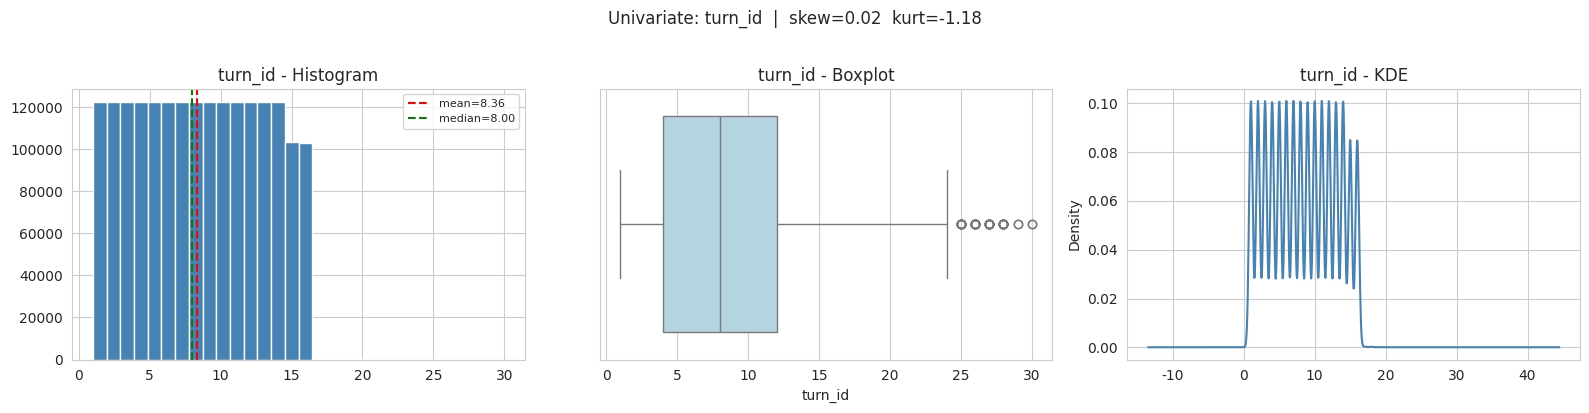

In [71]:
# 전체 수치형 컬럼 한번에 그리기
for col in num_cols:
    plot_numeric_univariate(df, col)

# 전체 수치형 한 화면에 비교 (컬럼 수 적을 때)
if 2 <= len(num_cols) <= 12:
    n = len(num_cols)
    ncols = 4
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
    axes = axes.flatten() if n > 1 else [axes]
    for i, col in enumerate(num_cols):
        df[col].hist(bins=30, ax=axes[i], color='steelblue', edgecolor='white')
        axes[i].set_title(col, fontsize=10)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('All Numeric Distributions', fontsize=14)
    plt.tight_layout()
    plt.show()

In [ ]:
# --- 5-2. 범주형: 빈도 막대 그래프 ---
# >>> 판단 포인트:
#     - 극단적 불균형(한 범주 90%+) → 모델링 시 클래스 불균형 처리 필요
#     - 카테고리 너무 많으면 → 그룹핑/인코딩 전략 필요
 
def plot_categorical_univariate(df, col, top_n=15):
    """범주형 컬럼의 빈도 분석 + 시각화"""
    vc = df[col].value_counts()
    print(f"\n--- {col} ---  (unique={df[col].nunique()}, top {min(top_n, len(vc))} shown)")
    print(vc.head(top_n))
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # 빈도 막대
    vc.head(top_n).plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
    axes[0].set_title(f'{col} - Value Counts (top {top_n})')
    axes[0].tick_params(axis='x', rotation=45)
    
    # 비율 파이 (카테고리 7개 이하일 때만)
    if len(vc) <= 7:
        vc.plot(kind='pie', ax=axes[1], autopct='%1.1f%%')
        axes[1].set_ylabel('')
        axes[1].set_title(f'{col} - Proportions')
    else:
        vc.head(top_n).plot(kind='barh', ax=axes[1], color='coral')
        axes[1].set_title(f'{col} - Horizontal (top {top_n})')
    
    plt.tight_layout()
    plt.show()
 
for col in cat_cols:
    plot_categorical_univariate(df, col)
 

# 6. 이변량 분석 (BIVARIATE ANALYSIS)

In [73]:
# ============================================================================
# 6. 이변량 분석 (BIVARIATE ANALYSIS)
# ============================================================================
 
# --- 6-1. 수치형 간 상관관계 ---
# >>> 판단 포인트:
#     - |r| > 0.8 → 다중공선성 의심 (VIF 추가 확인)
#     - 타겟과의 상관이 높은 피처 → 유용한 예측변수 후보
#     - Pearson은 선형만 잡음. 비선형 관계는 scatter로 직접 확인 필수
 
if len(num_cols) >= 2:
    corr = df[num_cols].corr()
    
    # 상관행렬 히트맵
    fig, ax = plt.subplots(figsize=(min(len(num_cols) * 1.2, 16), min(len(num_cols), 12)))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
    ax.set_title('Correlation Heatmap (Pearson)')
    plt.tight_layout()
    plt.show()
    
    # 높은 상관관계 쌍 추출 (|r| > threshold)
    threshold = 0.7
    high_corr_pairs = []
    for i in range(len(corr.columns)):
        for j in range(i + 1, len(corr.columns)):
            if abs(corr.iloc[i, j]) > threshold:
                high_corr_pairs.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))
    
    if high_corr_pairs:
        print(f"\n--- 높은 상관관계 쌍 (|r| > {threshold}) ---")
        for c1, c2, r in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
            print(f"  {c1} <-> {c2}: {r:.3f}")

In [74]:
# --- 6-3. 범주형 vs 수치형 ---
# >>> 판단 포인트:
#     - 그룹 간 분포 차이가 뚜렷하면 → 유의미한 피처
#     - boxplot 겹침이 심하면 → 해당 범주로는 구분력 낮음
 
def plot_cat_vs_num(df, cat_col, num_col):
    """범주형 x 수치형 비교 (boxplot + 그룹 통계)"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # boxplot
    order = df[cat_col].value_counts().index[:10]
    sns.boxplot(data=df, x=cat_col, y=num_col, order=order, ax=axes[0], palette='Set2')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].set_title(f'{num_col} by {cat_col}')
    
    # 그룹별 평균 막대
    group_mean = df.groupby(cat_col)[num_col].mean().sort_values(ascending=False).head(10)
    group_mean.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
    axes[1].set_title(f'Mean {num_col} by {cat_col}')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # 그룹 통계
    print(df.groupby(cat_col)[num_col].agg(['count', 'mean', 'median', 'std']).round(2))
 
# 사용 예: plot_cat_vs_num(df, 'category_col', 'numeric_col')

In [75]:
# --- 6-4. 범주형 vs 범주형 (교차표 + 카이제곱) ---
def plot_cat_vs_cat(df, col1, col2, top_n=10):
    """범주형 x 범주형 교차 분석"""
    ct = pd.crosstab(df[col1], df[col2])
    
    # 상위 카테고리만
    top1 = df[col1].value_counts().index[:top_n]
    top2 = df[col2].value_counts().index[:top_n]
    ct_sub = ct.loc[ct.index.isin(top1), ct.columns.isin(top2)]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 히트맵
    sns.heatmap(ct_sub, annot=True, fmt='d', cmap='YlOrBr', ax=axes[0])
    axes[0].set_title(f'Crosstab: {col1} x {col2}')
    
    # 누적 막대
    ct_norm = ct_sub.div(ct_sub.sum(axis=1), axis=0)
    ct_norm.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set2')
    axes[1].set_title(f'Proportions: {col1} x {col2}')
    axes[1].legend(bbox_to_anchor=(1.05, 1), fontsize=8)
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # 카이제곱 검정
    chi2, p, dof, expected = stats.chi2_contingency(ct)
    print(f"Chi-square: {chi2:.2f}, p-value: {p:.4f}, dof: {dof}")
    if p < 0.05:
        print("→ 유의수준 0.05에서 두 변수는 독립이 아님 (연관 있음)")
    else:
        print("→ 유의수준 0.05에서 두 변수의 독립성을 기각할 수 없음")
 
# 사용 예: plot_cat_vs_cat(df, 'col1', 'col2')

# 7. 이상치 탐지 (OUTLIER DETECTION)

In [79]:
# ============================================================================
# 7. 이상치 탐지 (OUTLIER DETECTION)
# ============================================================================
# >>> 판단 포인트:
#     - IQR 방식은 정규분포 가정. 비대칭 분포에선 과탐지 가능
#     - 이상치 = 반드시 제거 대상 아님. 도메인 지식으로 판단 필수
#     - 이상치가 전체의 5%+ 면 → 데이터 생성 과정 자체를 의심
 
def detect_outliers_iqr(df, col):
    """IQR 방식 이상치 탐지"""
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return outliers, lower, upper
 
def detect_outliers_zscore(df, col, threshold=3):
    """Z-score 방식 이상치 탐지"""
    z = np.abs(stats.zscore(df[col].dropna()))
    return df[col].dropna()[z > threshold]
 
print("\n--- OUTLIER SUMMARY (IQR Method) ---")
outlier_summary = []
for col in num_cols:
    outliers, lower, upper = detect_outliers_iqr(df, col)
    n_outliers = len(outliers)
    pct = n_outliers / len(df) * 100
    outlier_summary.append({
        'column': col,
        'n_outliers': n_outliers,
        'outlier_pct': round(pct, 2),
        'lower_bound': round(lower, 2),
        'upper_bound': round(upper, 2)
    })
 
outlier_df = pd.DataFrame(outlier_summary).sort_values('outlier_pct', ascending=False)
print(outlier_df.to_string(index=False))


--- OUTLIER SUMMARY (IQR Method) ---
 column  n_outliers  outlier_pct  lower_bound  upper_bound
turn_id          68         0.00        -8.00        24.00


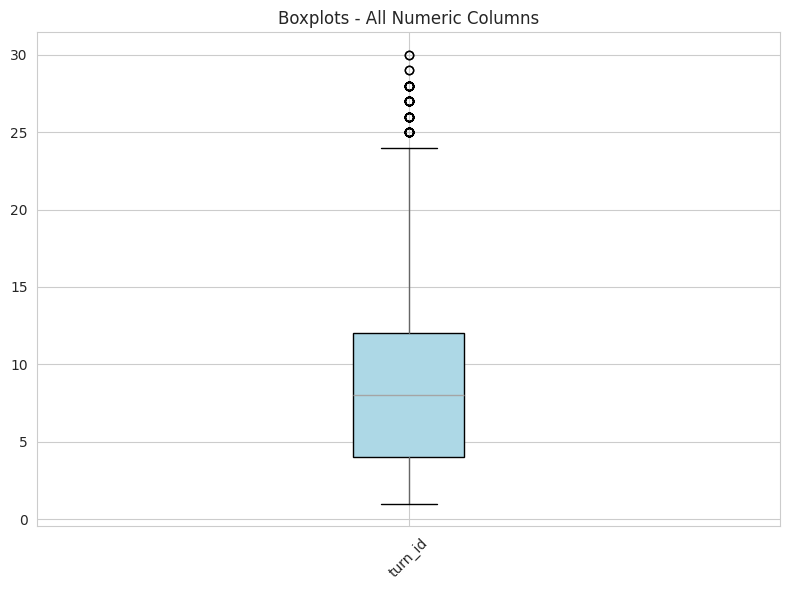

In [77]:
# 이상치 시각화 (전체 수치형)
if len(num_cols) > 0:
    fig, ax = plt.subplots(figsize=(max(len(num_cols) * 1.2, 8), 6))
    df[num_cols].boxplot(ax=ax, vert=True, patch_artist=True,
                          boxprops=dict(facecolor='lightblue'))
    ax.set_title('Boxplots - All Numeric Columns')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

# 8. 타겟 변수 분석

In [82]:
# ============================================================================
# 8. 타겟 변수 분석
# ============================================================================
# >>> 사용 전 target_col을 지정할 것
 
target_col = 'target'  # ← 여기를 수정
 
if target_col in df.columns:
    print(f"\n--- TARGET: {target_col} ---")
    print(df[target_col].describe())
    
    # 분류 문제 (타겟이 범주형이거나 유니크 < 20)
    if df[target_col].dtype == 'object' or df[target_col].nunique() < 20:
        print("\n[분류 문제로 판단]")
        vc = df[target_col].value_counts()
        print(vc)
        print(f"\n클래스 비율:\n{(vc / len(df) * 100).round(2)}")
        
        # 불균형 체크
        imbalance_ratio = vc.max() / vc.min()
        print(f"불균형 비율 (max/min): {imbalance_ratio:.1f}")
        if imbalance_ratio > 3:
            print("⚠️ 클래스 불균형 심함 → SMOTE, 가중치 조정, 언더샘플링 고려")
        
        # 타겟 분포 시각화
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        vc.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
        axes[0].set_title(f'Target Distribution: {target_col}')
        axes[0].tick_params(axis='x', rotation=0)
        vc.plot(kind='pie', ax=axes[1], autopct='%1.1f%%')
        axes[1].set_ylabel('')
        plt.tight_layout()
        plt.show()
        
        # 타겟별 수치형 비교
        for col in num_cols:
            if col != target_col:
                fig, ax = plt.subplots(figsize=(10, 4))
                for label in df[target_col].unique():
                    subset = df[df[target_col] == label][col].dropna()
                    subset.plot(kind='kde', ax=ax, label=str(label), alpha=0.7)
                ax.set_title(f'{col} distribution by {target_col}')
                ax.legend()
                plt.tight_layout()
                plt.show()
    
    # 회귀 문제 (타겟이 연속형)
    else:
        print("\n[회귀 문제로 판단]")
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        df[target_col].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
        axes[0].set_title(f'Target Distribution: {target_col}')
        stats.probplot(df[target_col].dropna(), dist="norm", plot=axes[1])
        axes[1].set_title('Q-Q Plot (Normality Check)')
        plt.tight_layout()
        plt.show()
        
        # 타겟과 수치형 변수 간 상관
        if len(num_cols) > 1:
            target_corr = df[num_cols].corr()[target_col].drop(target_col).sort_values(ascending=False)
            print(f"\n타겟 상관계수:\n{target_corr}")
            
            fig, ax = plt.subplots(figsize=(10, max(len(target_corr) * 0.4, 4)))
            target_corr.plot(kind='barh', ax=ax, color=target_corr.apply(
                lambda x: 'steelblue' if x > 0 else 'salmon'))
            ax.set_title(f'Correlation with {target_col}')
            ax.axvline(0, color='black', linewidth=0.5)
            plt.tight_layout()
            plt.show()
 

In [ ]:
    # 회귀 문제 (타겟이 연속형)
    else:
        print("\n[회귀 문제로 판단]")
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        df[target_col].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
        axes[0].set_title(f'Target Distribution: {target_col}')
        stats.probplot(df[target_col].dropna(), dist="norm", plot=axes[1])
        axes[1].set_title('Q-Q Plot (Normality Check)')
        plt.tight_layout()
        plt.show()
        
        # 타겟과 수치형 변수 간 상관
        if len(num_cols) > 1:
            target_corr = df[num_cols].corr()[target_col].drop(target_col).sort_values(ascending=False)
            print(f"\n타겟 상관계수:\n{target_corr}")
            
            fig, ax = plt.subplots(figsize=(10, max(len(target_corr) * 0.4, 4)))
            target_corr.plot(kind='barh', ax=ax, color=target_corr.apply(
                lambda x: 'steelblue' if x > 0 else 'salmon'))
            ax.set_title(f'Correlation with {target_col}')
            ax.axvline(0, color='black', linewidth=0.5)
            plt.tight_layout()
            plt.show()
 

# 9. 시계열 데이터 추가 체크 (해당 시)

In [83]:
# ============================================================================
# 9. 시계열 데이터 추가 체크 (해당 시)
# ============================================================================
# >>> 날짜 컬럼이 있을 때만 사용. date_col을 수정할 것.
 
date_col = None  # ← 날짜 컬럼명으로 수정 (예: 'date')
 
if date_col and date_col in df.columns:
    df[date_col] = pd.to_datetime(df[date_col])
    df_sorted = df.sort_values(date_col)
    
    print(f"\n--- TIME SERIES CHECK: {date_col} ---")
    print(f"기간: {df_sorted[date_col].min()} ~ {df_sorted[date_col].max()}")
    print(f"총 일수: {(df_sorted[date_col].max() - df_sorted[date_col].min()).days}")
    
    # 일별 레코드 수 (데이터 빈도 확인)
    daily_counts = df_sorted.set_index(date_col).resample('D').size()
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    
    # 레코드 수 추이
    daily_counts.plot(ax=axes[0], color='steelblue')
    axes[0].set_title('Daily Record Count')
    
    # 수치형 변수 시계열 추이
    for col in num_cols[:3]:  # 상위 3개만
        df_sorted.set_index(date_col)[col].plot(ax=axes[1], alpha=0.7, label=col)
    axes[1].legend()
    axes[1].set_title('Numeric Columns Over Time')
    
    plt.tight_layout()
    plt.show()
    
    # 요일/월별 패턴
    df_sorted['_dayofweek'] = df_sorted[date_col].dt.day_name()
    df_sorted['_month'] = df_sorted[date_col].dt.month
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    df_sorted['_dayofweek'].value_counts().reindex(
        ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    ).plot(kind='bar', ax=axes[0], color='steelblue')
    axes[0].set_title('Records by Day of Week')
    
    df_sorted['_month'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='coral')
    axes[1].set_title('Records by Month')
    
    plt.tight_layout()
    plt.show()
    
    # 임시 컬럼 정리
    df_sorted.drop(columns=['_dayofweek', '_month'], inplace=True, errors='ignore')

# 10. 텍스트 데이터 추가 체크 (해당 시)


--- TEXT ANALYSIS: text ---
문자 수 통계:
count   1923481.00
mean         57.93
std          35.37
min           3.00
25%          33.00
50%          50.00
75%          72.00
max         542.00
Name: _text_len, dtype: float64

단어 수 통계:
count   1923481.00
mean         13.32
std           7.93
min           1.00
25%           8.00
50%          12.00
75%          17.00
max         152.00
Name: _word_count, dtype: float64


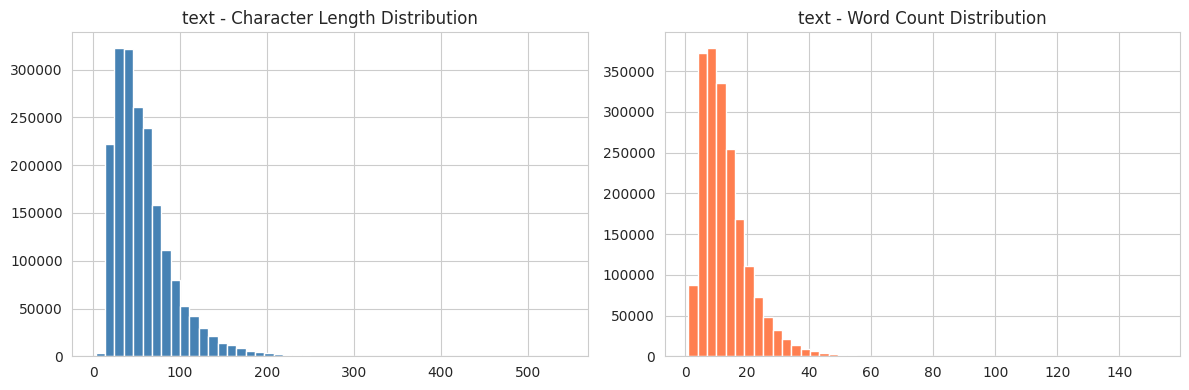

In [84]:
# ============================================================================
# 10. 텍스트 데이터 추가 체크 (해당 시)
# ============================================================================
# >>> 텍스트 컬럼이 있을 때. text_col을 수정할 것.
 
text_col = 'text'  # ← 텍스트 컬럼명으로 수정
 
if text_col and text_col in df.columns:
    print(f"\n--- TEXT ANALYSIS: {text_col} ---")
    
    # 기본 통계
    df['_text_len'] = df[text_col].astype(str).str.len()
    df['_word_count'] = df[text_col].astype(str).str.split().str.len()
    
    print(f"문자 수 통계:\n{df['_text_len'].describe()}")
    print(f"\n단어 수 통계:\n{df['_word_count'].describe()}")
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    df['_text_len'].hist(bins=50, ax=axes[0], color='steelblue')
    axes[0].set_title(f'{text_col} - Character Length Distribution')
    df['_word_count'].hist(bins=50, ax=axes[1], color='coral')
    axes[1].set_title(f'{text_col} - Word Count Distribution')
    plt.tight_layout()
    plt.show()
    
    # 임시 컬럼 정리
    df.drop(columns=['_text_len', '_word_count'], inplace=True, errors='ignore')

# 11. 피처 엔지니어링 힌트

In [85]:
# ============================================================================
# 11. 피처 엔지니어링 힌트
# ============================================================================
# >>> 자동으로 할 수 있는 기본 점검들
 
print("\n" + "=" * 60)
print("FEATURE ENGINEERING HINTS")
print("=" * 60)
 
# 로그 변환 후보 (skew > 1)
skewed = df[num_cols].skew()
high_skew = skewed[abs(skewed) > 1].sort_values(ascending=False)
if len(high_skew) > 0:
    print(f"\n[로그/제곱근 변환 후보 (|skew| > 1)]")
    for col, sk in high_skew.items():
        print(f"  {col}: skew={sk:.2f}")
 
# 원-핫 인코딩 후보 (범주형 + unique < 10)
ohe_candidates = [col for col in cat_cols if df[col].nunique() < 10]
if ohe_candidates:
    print(f"\n[원-핫 인코딩 후보 (unique < 10)]: {ohe_candidates}")
 
# 타겟 인코딩 / 빈도 인코딩 후보 (high cardinality)
high_card = [col for col in cat_cols if df[col].nunique() >= 10]
if high_card:
    print(f"\n[타겟/빈도 인코딩 후보 (unique >= 10)]: {high_card}")
 
# 스케일링 필요 여부
if len(num_cols) >= 2:
    ranges = df[num_cols].max() - df[num_cols].min()
    if ranges.max() / (ranges.min() + 1e-10) > 100:
        print(f"\n[스케일링 권장] 수치형 변수 간 범위 차이가 100배 이상")
        print(f"  Min range: {ranges.min():.2f} ({ranges.idxmin()})")
        print(f"  Max range: {ranges.max():.2f} ({ranges.idxmax()})")


FEATURE ENGINEERING HINTS

[원-핫 인코딩 후보 (unique < 10)]: ['dataset', 'speaker_role', 'topic_large', 'category', 'speaker_age', 'speaker_gender']

[타겟/빈도 인코딩 후보 (unique >= 10)]: ['doc_id', 'session_id', 'speaker_id', 'text', 'topic_raw', 'topic_medium', 'topic_small', 'source_file', 'speaker_occupation', 'session_summary', 'prev_session_id', 'prev_aggregated_summary', 'context_query', 'context_document_title']


# 12. EDA 요약 리포트 자동 생성

In [86]:
def eda_summary_report(df):
    """EDA 결과를 텍스트로 요약"""
    report = []
    report.append("=" * 60)
    report.append("EDA SUMMARY REPORT")
    report.append("=" * 60)
    report.append(f"\n데이터 크기: {df.shape[0]:,} rows × {df.shape[1]} columns")
    report.append(f"수치형: {len(num_cols)}개, 범주형: {len(cat_cols)}개, 날짜형: {len(date_cols)}개")
    
    # 결측
    total_missing = df.isnull().sum().sum()
    total_cells = df.shape[0] * df.shape[1]
    report.append(f"\n총 결측: {total_missing:,} / {total_cells:,} ({total_missing/total_cells*100:.2f}%)")
    cols_with_missing = df.columns[df.isnull().any()].tolist()
    if cols_with_missing:
        report.append(f"결측 포함 컬럼({len(cols_with_missing)}): {cols_with_missing}")
    
    # 중복
    n_dup = df.duplicated().sum()
    report.append(f"\n중복 행: {n_dup:,} ({n_dup/len(df)*100:.2f}%)")
    
    # 이상치 요약
    if len(num_cols) > 0:
        report.append(f"\n이상치 (IQR):")
        for col in num_cols:
            outliers, _, _ = detect_outliers_iqr(df, col)
            pct = len(outliers) / len(df) * 100
            if pct > 1:
                report.append(f"  {col}: {len(outliers):,}개 ({pct:.1f}%)")
    
    # 고카디널리티
    for col in cat_cols:
        if df[col].nunique() > 50:
            report.append(f"\n 고카디널리티: {col} (unique={df[col].nunique()})")
    
    report.append("\n" + "=" * 60)
    return "\n".join(report)
 
print(eda_summary_report(df))

EDA SUMMARY REPORT

데이터 크기: 1,923,481 rows × 21 columns
수치형: 1개, 범주형: 20개, 날짜형: 0개

총 결측: 4,062,751 / 40,393,101 (10.06%)
결측 포함 컬럼(4): ['text', 'prev_session_id', 'context_query', 'context_document_title']

중복 행: 0 (0.00%)

이상치 (IQR):

 고카디널리티: doc_id (unique=49206)

 고카디널리티: session_id (unique=122605)

 고카디널리티: speaker_id (unique=1688)

 고카디널리티: text (unique=1654798)

 고카디널리티: source_file (unique=49206)

 고카디널리티: session_summary (unique=121342)

 고카디널리티: prev_session_id (unique=73401)

 고카디널리티: prev_aggregated_summary (unique=73402)

 고카디널리티: context_query (unique=63134)

 고카디널리티: context_document_title (unique=65765)

